In [2]:
# STEP 1: IMPORT LIBRARIES & LOAD DATA
# 1.1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 1.2. LOAD DATA
df = pd.read_csv("Telco_churn_clean.csv")
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [17]:
# 1.3. VIEW TOP 5 ROWS
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# 1.4. GET BASIC INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
# 1.5. CHECK SHAPE
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [16]:
# 1.6. CHECK FOR MISSING VALUES
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# 1.7. CHECK DUPLICATES
df.duplicated().sum()

np.int64(0)

In [14]:
# 1.8. CHECK DATA TYPES & UNIQUE VALUES IN CATEGORICAL COLUMNS
for col in df.select_dtypes(include = 'object').columns:
    print(f"\n{col}:{df[col].unique()}")


customerID:['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:['Female' 'Male']

Partner:['Yes' 'No']

Dependents:['No' 'Yes']

PhoneService:['No' 'Yes']

MultipleLines:['No phone service' 'No' 'Yes']

InternetService:['DSL' 'Fiber optic' 'No']

OnlineSecurity:['No' 'Yes' 'No internet service']

OnlineBackup:['Yes' 'No' 'No internet service']

DeviceProtection:['No' 'Yes' 'No internet service']

TechSupport:['No' 'Yes' 'No internet service']

StreamingTV:['No' 'Yes' 'No internet service']

StreamingMovies:['No' 'Yes' 'No internet service']

Contract:['Month-to-month' 'One year' 'Two year']

PaperlessBilling:['Yes' 'No']

PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:['No' 'Yes']


In [13]:
# STEP 2: UNIVARIATE ANALYSIS
# 2.1. NUMERIC DISTRIBUTIONS
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    print(f"\n---{col}---")
    print(df[col].describe())


---tenure---
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

---MonthlyCharges---
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

---TotalCharges---
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


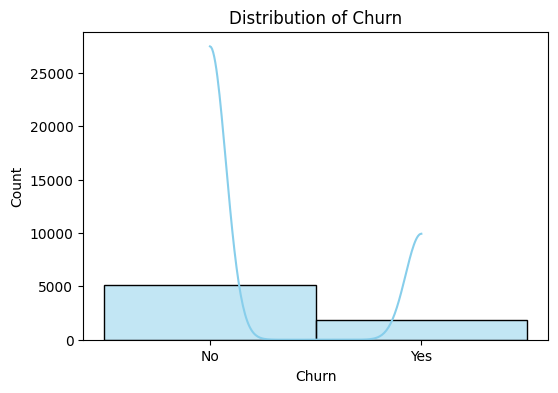

In [20]:
# GRAPHICAL REPRESENTATION
plt.figure(figsize = (6,4))
sns.histplot(df[col], kde = True, bins = 30, color = 'skyblue')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Count")
plt.show()

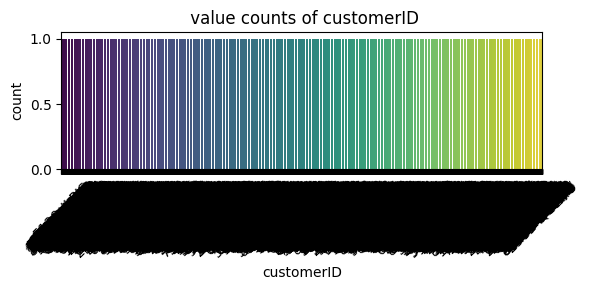

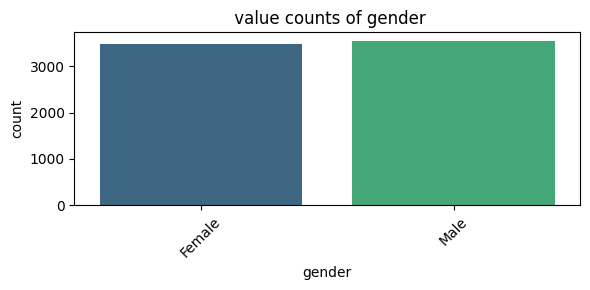

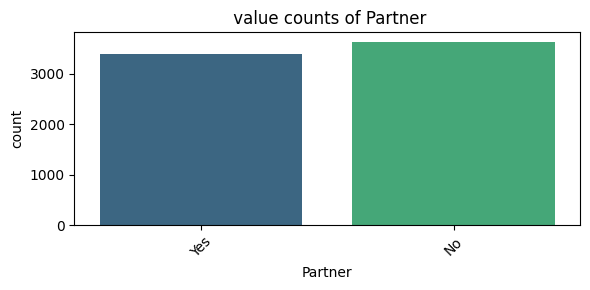

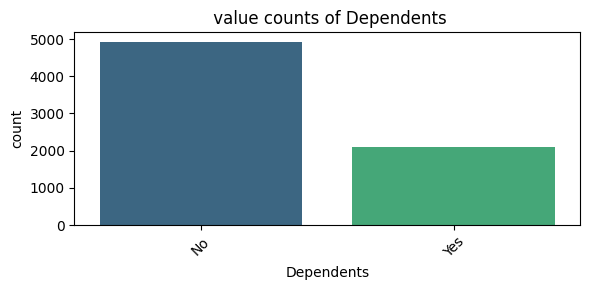

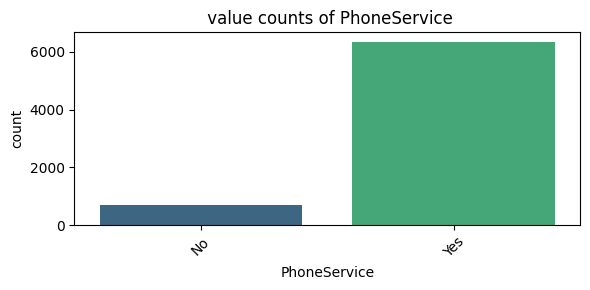

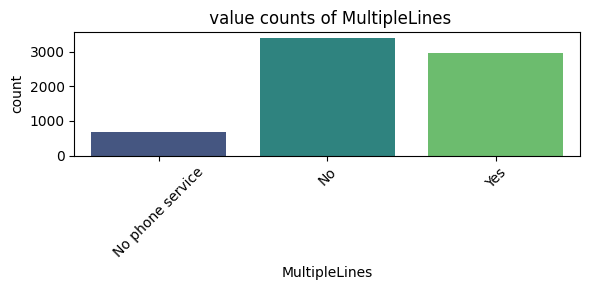

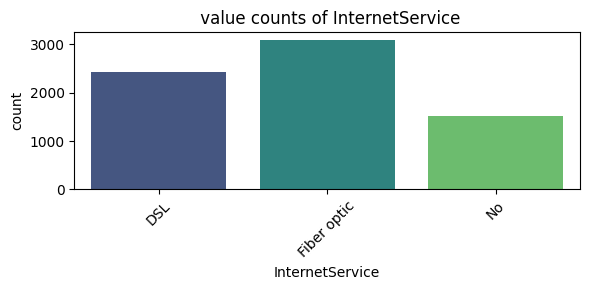

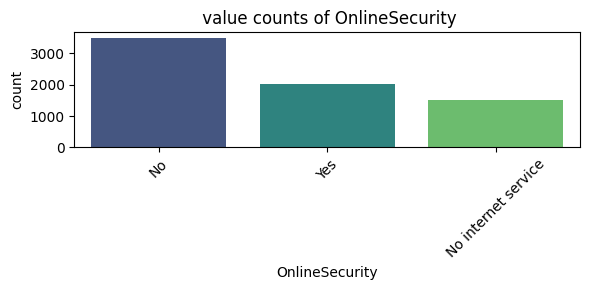

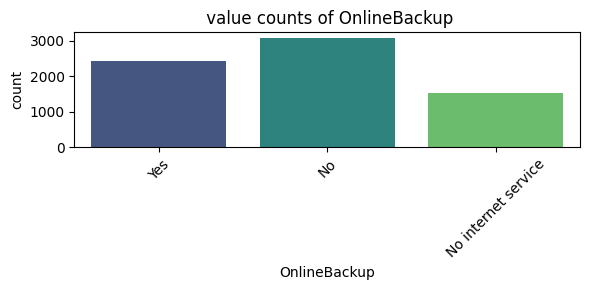

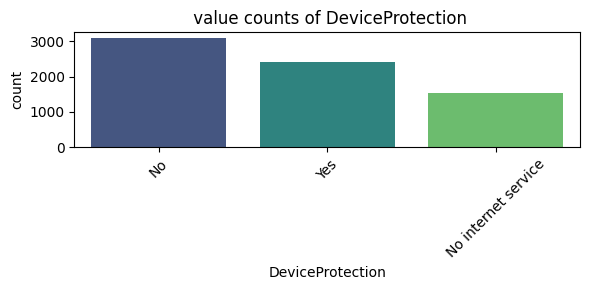

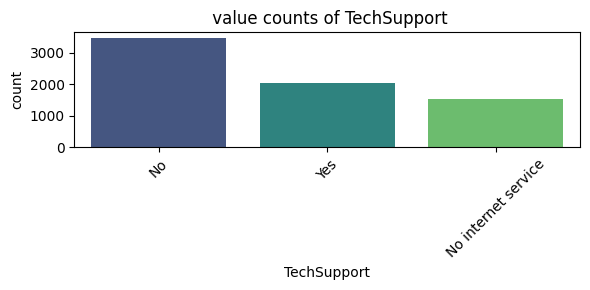

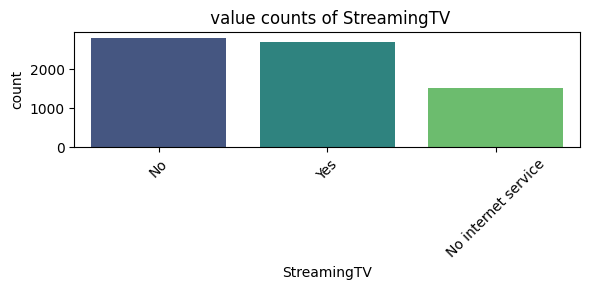

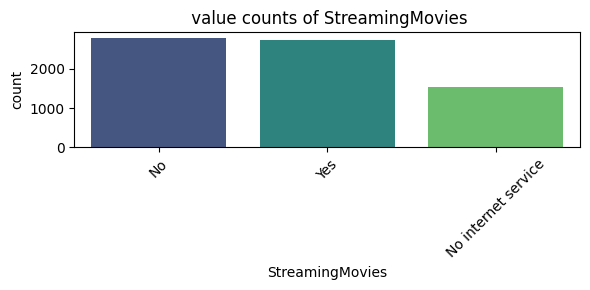

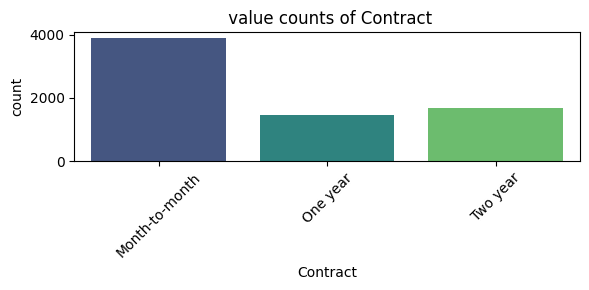

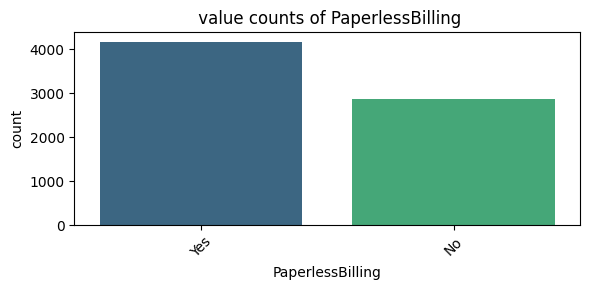

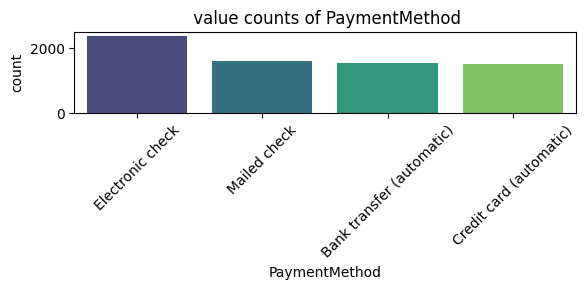

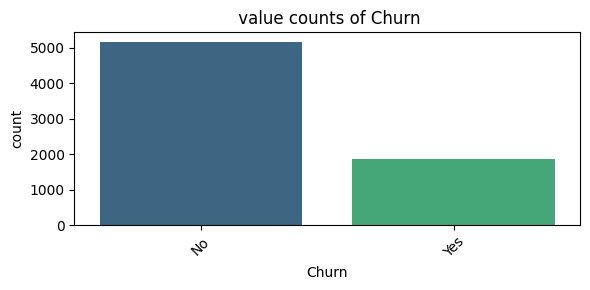

In [28]:
# 2.2. CATEGORICAL DISTRIBUTIONS

cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in ['customer ID']]
for col in cat_cols:
    plt.figure(figsize = (6,3))
    sns.countplot(data=df, x=col, hue=col, legend=False, palette="viridis")
    plt.title (f" value counts of {col}")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

In [5]:
# STEP 3: BIVARIATE ANALYSIS
# 3.1. CHURN V/S GENDER

gender_churn = df.groupby('gender')['Churn'].value_counts(normalize = True).unstack()*100
gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


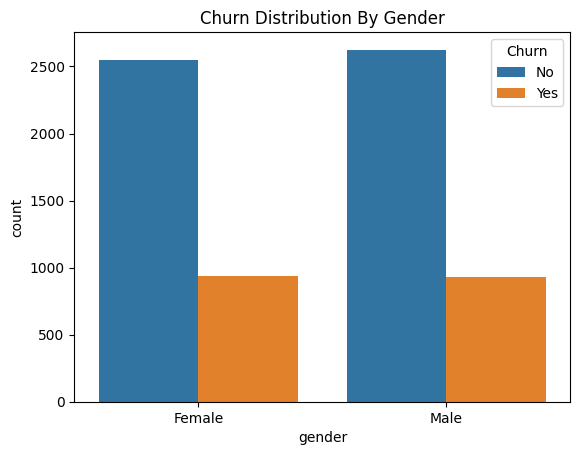

In [4]:
# GRAPHICAL REPRESENTATION OF CHURN V/S GENDER
sns.countplot(x='gender',hue='Churn',data=df)
plt.title('Churn Distribution By Gender')
plt.show()

In [34]:
# 3.2 CHURN V/S SENIOR CITIZEN

senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize = True).unstack()*100
senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


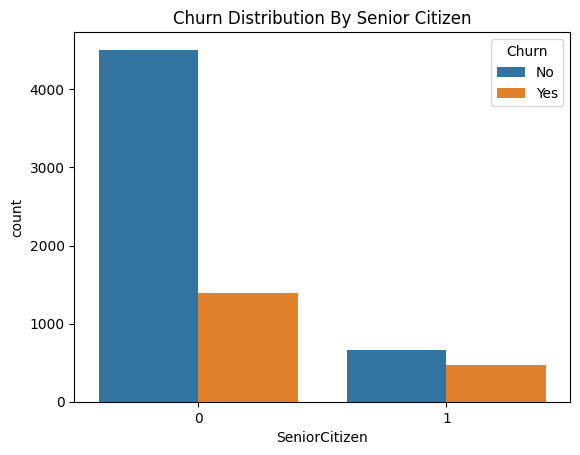

In [31]:
# GRAPHICAL REPRESENTATION OF CHURN V/S SENIOR CITIZEN
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title('Churn Distribution By Senior Citizen')
plt.show()

In [25]:
# 3.3. CHURN V/S PARTNER
partner_churn =df.groupby('Partner')['Churn'].value_counts(normalize = True).unstack()*100
partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


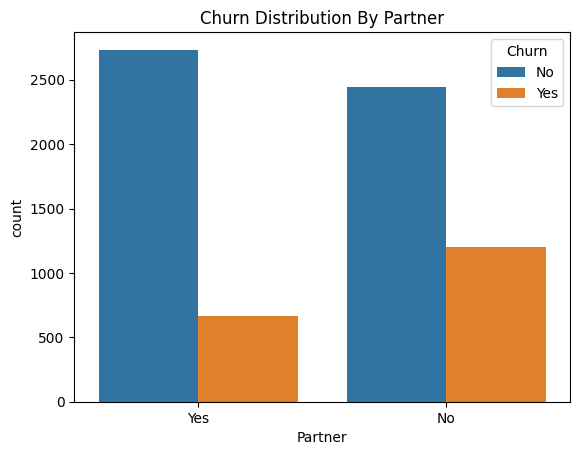

In [27]:
# GRAPHICAL REPRESENTATION OF CHURN V/S PARTNER
sns.countplot(x='Partner',hue='Churn',data=df)
plt.title('Churn Distribution By Partner')
plt.show()

In [35]:
# 3.4. CHURN V/S DEPENDENTS
pd.crosstab(df['Dependents'],df['Churn'],normalize='index')*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


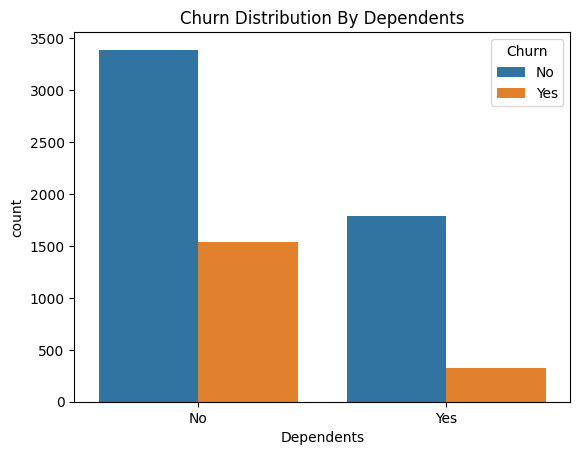

In [36]:
# GRAPHICAL REPRESENTATION OF CHURN V/S DEPENDENTS
sns.countplot(x='Dependents',hue='Churn',data=df)
plt.title('Churn Distribution By Dependents')
plt.show()

In [37]:
# 3.5. CHURN V/S PHONE SERVICE
pd.crosstab(df['PhoneService'],df['Churn'],normalize='index')*100

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


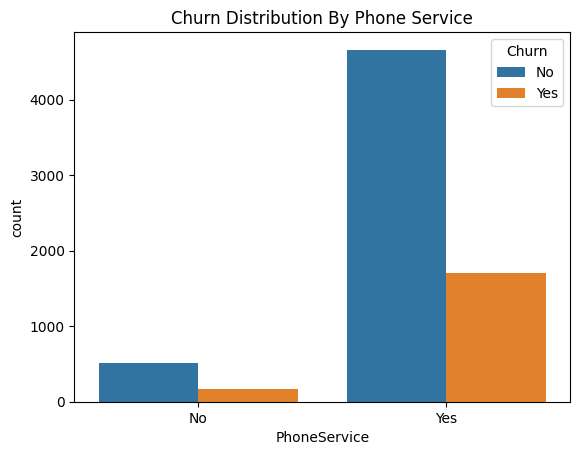

In [38]:
# GRAPHICAL REPRESENTATION OF CHURN V/S PHONE SERVICE
sns.countplot(x='PhoneService',hue='Churn',data=df)
plt.title('Churn Distribution By Phone Service')
plt.show()

In [39]:
# 3.6. CHURN V/S INTERNET SERVICE
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


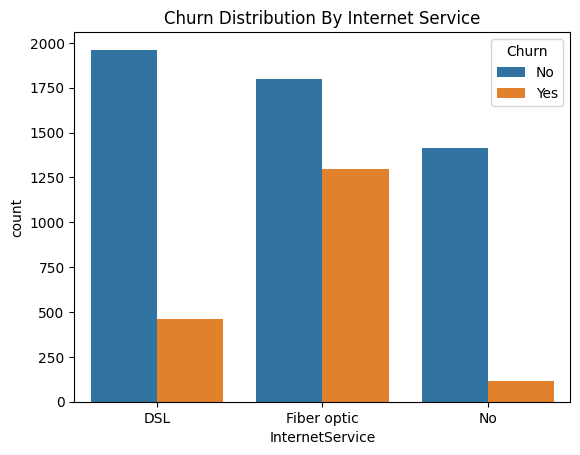

In [40]:
# GRAPHICAL REPRESENTATION OF CHURN V/S INTERNET SERVICE
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title('Churn Distribution By Internet Service')
plt.show()

In [41]:
# 3.7. CHURN V/S MULTIPLE LINES
pd.crosstab(df['MultipleLines'],df['Churn'],normalize='index')*100

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


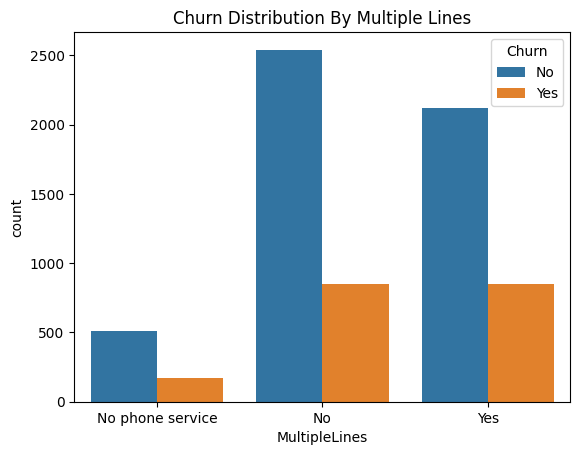

In [42]:
# GRAPHICAL REPRESENTATION OF CHURN V/S MULTIPLE LINES
sns.countplot(x='MultipleLines',hue='Churn',data=df)
plt.title('Churn Distribution By Multiple Lines')
plt.show()

In [43]:
# 3.8. CHURN V/S ONLINE SECURITY
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


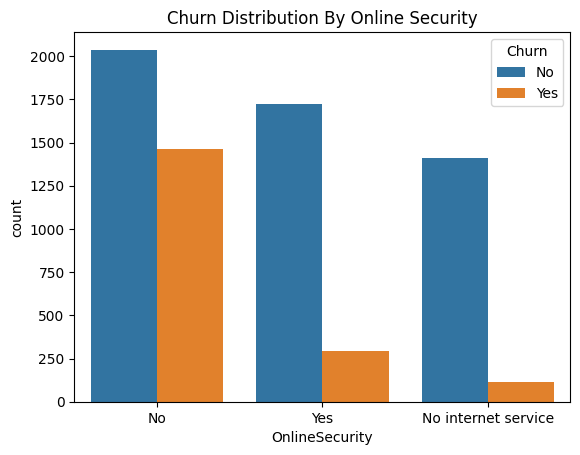

In [45]:
# GRAPHICAL REPRESENTATION OF CHURN V/S ONLINE SECURITY
sns.countplot(x='OnlineSecurity',hue='Churn',data=df)
plt.title('Churn Distribution By Online Security')
plt.show()

In [46]:
# 3.9. CHURN V/S ONLINE BACKUP
pd.crosstab(df['OnlineBackup'],df['Churn'],normalize='index')*100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


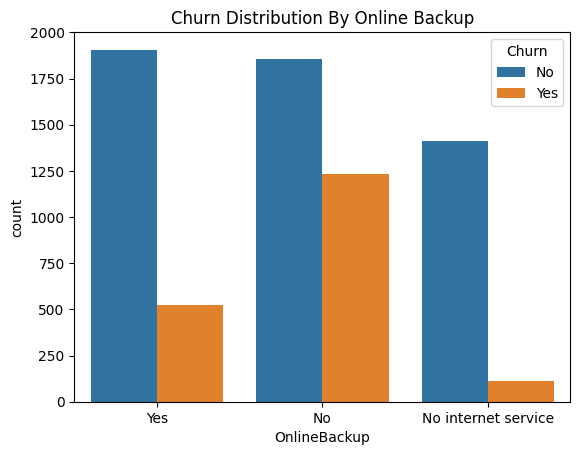

In [47]:
# GRAPHICAL REPRESENTATION OF CHURN V/S ONLINE BACKUP
sns.countplot(x='OnlineBackup',hue='Churn',data=df)
plt.title('Churn Distribution By Online Backup')
plt.show()

In [48]:
# 3.10. CHURN V/S DEVICE PROTECTION
pd.crosstab(df['DeviceProtection'],df['Churn'],normalize='index')*100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


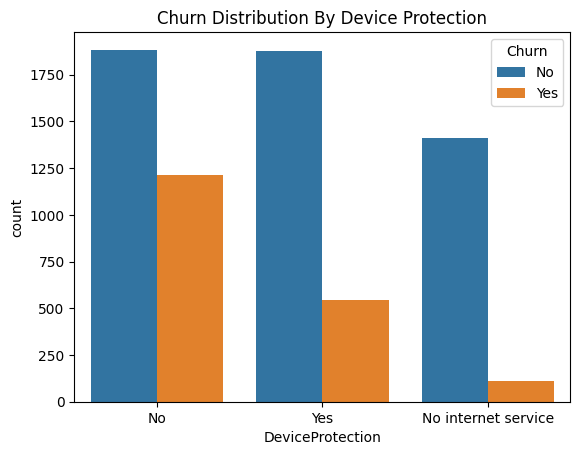

In [49]:
# GRAPHICAL REPRESENTATION OF CHURN V/S DEVICE PROTECTION
sns.countplot(x='DeviceProtection',hue='Churn',data=df)
plt.title('Churn Distribution By Device Protection')
plt.show()

In [50]:
# 3.11. CHURN V/S TECH SUPPORT
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


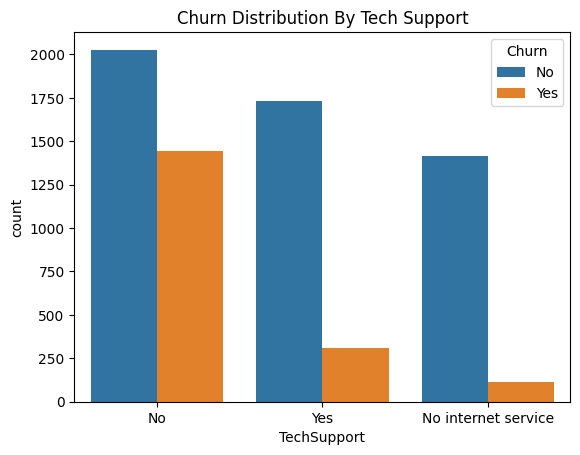

In [51]:
# GRAPHICAL REPRESENTATION OF CHURN V/S TECH SUPPORT
sns.countplot(x='TechSupport',hue='Churn',data=df)
plt.title('Churn Distribution By Tech Support')
plt.show()

In [52]:
# 3.12. CHURN V/S STREAMING TV
pd.crosstab(df['StreamingTV'],df['Churn'],normalize='index')*100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


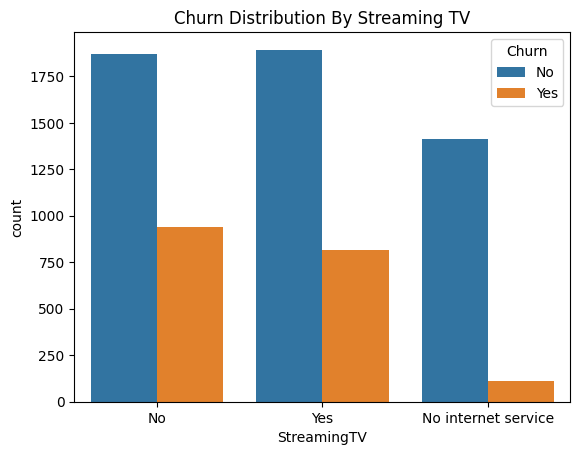

In [53]:
# GRAPHICAL REPRESENTATION OF CHURN V/S STREAMING TV
sns.countplot(x='StreamingTV',hue='Churn',data=df)
plt.title('Churn Distribution By Streaming TV')
plt.show()

In [54]:
# 3.13. CHURN V/S STREAMING MOVIES
pd.crosstab(df['StreamingMovies'],df['Churn'],normalize='index')*100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


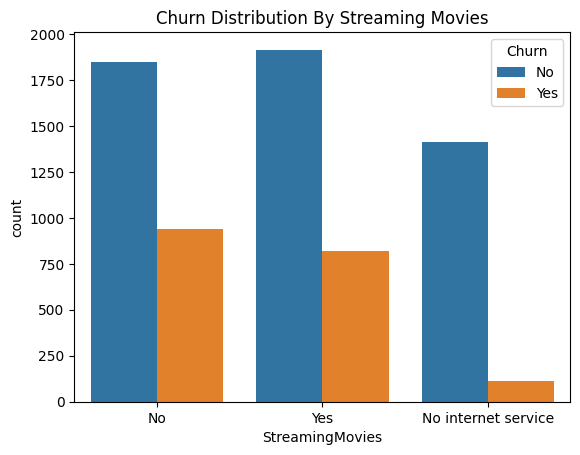

In [55]:
# GRAPHICAL REPRESENTATION OF CHURN V/S STREAMING MOVIES
sns.countplot(x='StreamingMovies',hue='Churn',data=df)
plt.title('Churn Distribution By Streaming Movies')
plt.show()

In [56]:
# 3.14. CHURN V/S CONTRACT
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


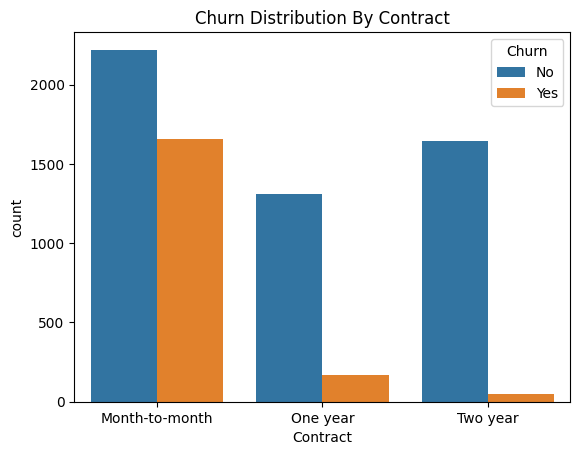

In [57]:
# GRAPHICAL REPRESENTATION OF CHURN V/S CONTRACT
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('Churn Distribution By Contract')
plt.show()

In [58]:
# 3.15. CHURN V/S PAPERLESS BILLING
pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


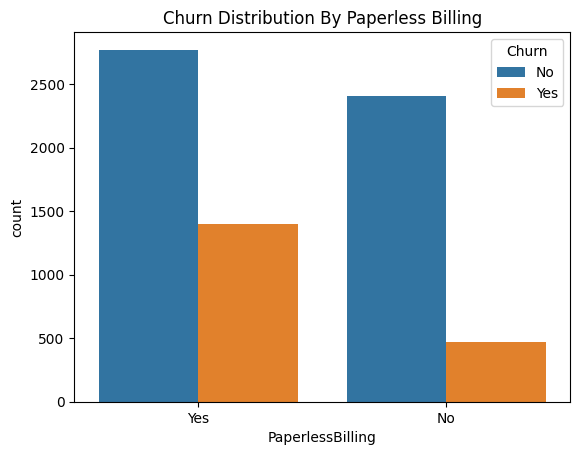

In [59]:
# GRAPHICAL REPRESENTATION OF CHURN V/S PAPERLESS BILLING
sns.countplot(x='PaperlessBilling',hue='Churn',data=df)
plt.title('Churn Distribution By Paperless Billing')
plt.show()

In [60]:
# 3.16. CHURN V/S PAYMENT METHOD
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


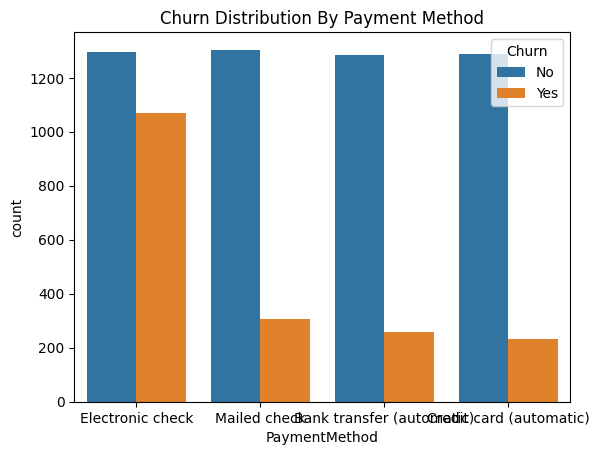

In [11]:
# GRAPHICAL REPRESENTATION OF CHURN V/S PAYMENT METHOD
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.title('Churn Distribution By Payment Method')
plt.show()

In [61]:
# 3.17. CHURN V/S TENURE
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


<Figure size 800x500 with 0 Axes>

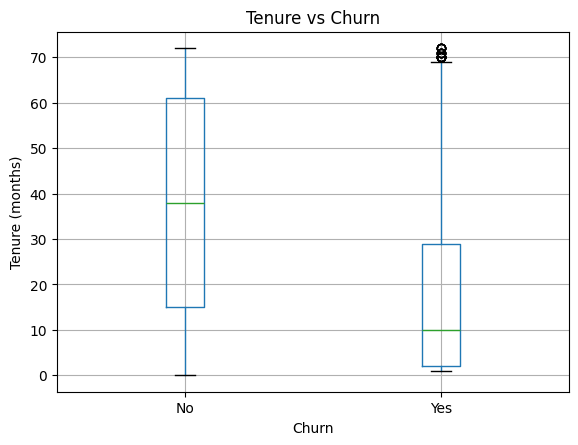

In [64]:
# GRAPHICAL REPRESENTATION OF CHURN V/S TENURE
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column='tenure', by='Churn')
plt.title('Tenure vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()

In [62]:
# 3.18. CHURN V/S MONTHLY CHARGES
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


<Figure size 800x500 with 0 Axes>

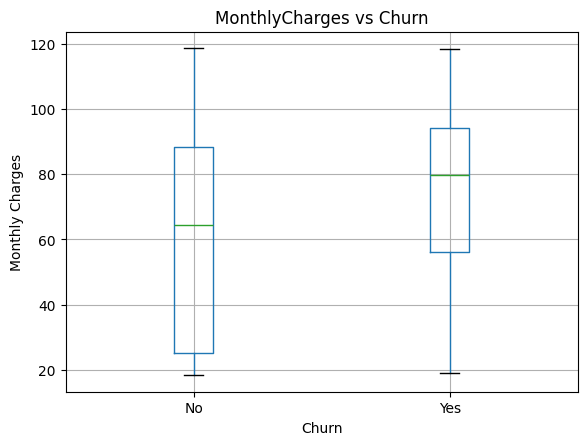

In [66]:
# GRAPHICAL REPRESENTATION OF CHURN V/S MONTHLY CHARGES
plt.figure(figsize=(8,5))
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('MonthlyCharges vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

In [67]:
# 3.19. CHURN V/S TOTAL CHARGES
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


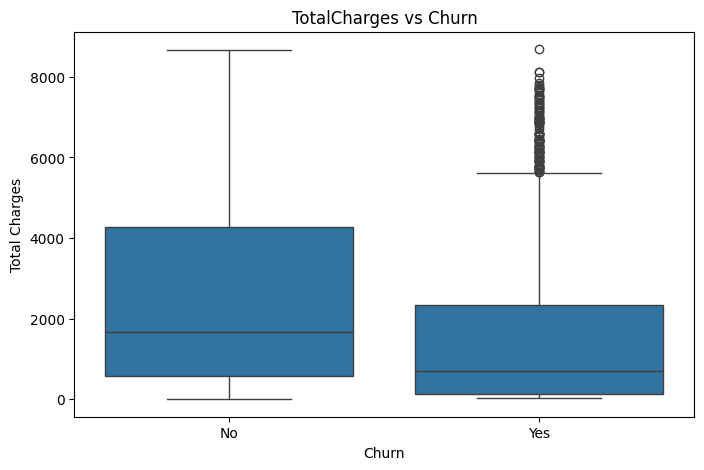

In [68]:
# GRAPHICAL REPRESENTATION OF CHURN V/S TOTAL CHARGES
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('TotalCharges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

In [69]:
# STEP 4: MULTIVARIATE ANALYSIS
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


In [70]:
# STEP 5: RELATIONSHIP BETWEEN NUMERICAL VARIABLES AND CHURN
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [73]:
# STEP 6: RELATIONSHIP BETWEEN CONTRACT TYPE AND TENURE
df.groupby('Contract')['tenure'].mean()

Contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

In [72]:
# STEP 7: RELATIONSHIP BETWEEN PAYMENT METHOD AND MONTHLY CHARGES
df.groupby('PaymentMethod')['MonthlyCharges'].mean()

PaymentMethod
Bank transfer (automatic)    67.192649
Credit card (automatic)      66.512385
Electronic check             76.255814
Mailed check                 43.917060
Name: MonthlyCharges, dtype: float64

In [74]:
# STEP 8: COMBINED SERVICE IMPACT ON CHURN
# Create a new column that counts how many of these 3 services a customer has
df['TotalServices'] = ((df['OnlineSecurity'] == 'Yes').astype(int) + (df['OnlineBackup'] == 'Yes').astype(int) + (df['TechSupport'] == 'Yes').astype(int))

# Calculate churn percentages based on total services
service_churn = (df.groupby('TotalServices')['Churn'].value_counts(normalize=True).unstack() * 100).round(2)
print(service_churn)

Churn             No    Yes
TotalServices              
0              67.95  32.05
1              67.81  32.19
2              84.50  15.50
3              93.18   6.82


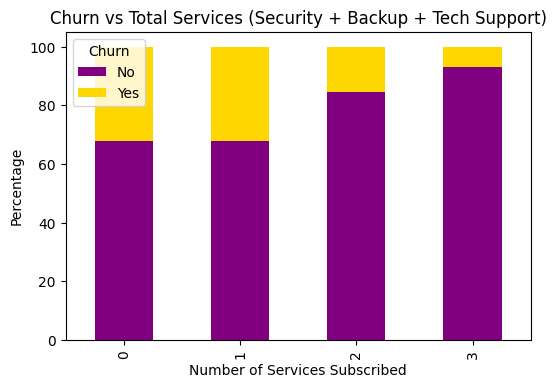

In [75]:
# GRAPHICAL REPRESENTATION OF COMBINED SERVICE IMPACT ON CHURN
service_churn.plot(kind='bar', stacked=True, color=['purple', 'gold'], figsize=(6,4))
plt.title('Churn vs Total Services (Security + Backup + Tech Support)')
plt.ylabel('Percentage')
plt.xlabel('Number of Services Subscribed')
plt.legend(title='Churn')
plt.show()